Ejercicio 1. 
Recorta el punto de interés de la imagen1.jpg tal cual se muestra en la figura, guarda la 
imagen recortada en tu disco local, y muestra la imagen original y la recortada con axis 
(imagen a colores)

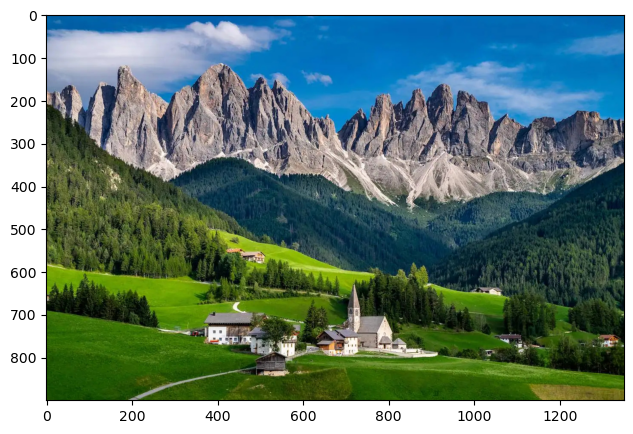

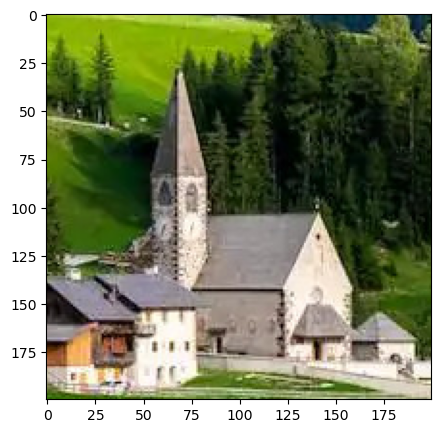

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams ['figure.figsize']=[15,5]
imagen=cv2.imread('imagen1.jpg')
imagen_rgb= cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

#MOSTRANDO UNA IMAGE
plt.imshow(imagen_rgb)
plt.show()

#seleccionando un punto de interes

plt.imshow(imagen_rgb[600:800,650:850,::])

plt.show()

#guardado de imagen seleccionada
img_cortada=imagen_rgb[600:800,650:850,:]
plt.imsave('img_cortada.jpg', img_cortada)

Ejercicio 2. 
Genera un degradado lineal a colores. 

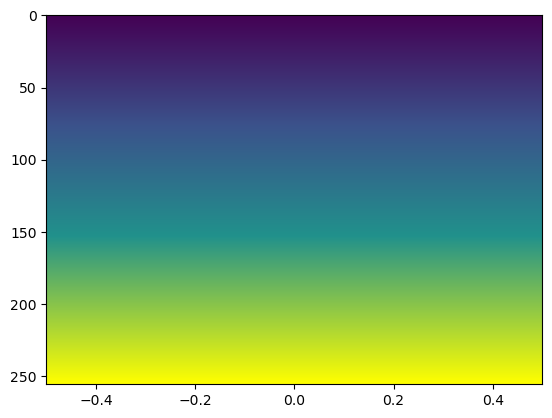

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

#Definicion de colores

colores=[(0,'#440154'),(0.3,'#3b528b'),(0.6,'#21918c'),(1,'yellow')] # para escoger los colers
cmap=LinearSegmentedColormap.from_list('degradado',colores)#listar los colores y generara color map a traves del array
img_degradada=cmap(np.linspace(0,1,256).reshape(-1,1))


plt.imshow(img_degradada,aspect='auto')
plt.show()

Ejercicio 3. 
Genera una imagen semejante a un tablero de ajedrez tomando en cuenta que cada 
casilla debe medir 100x100 px   

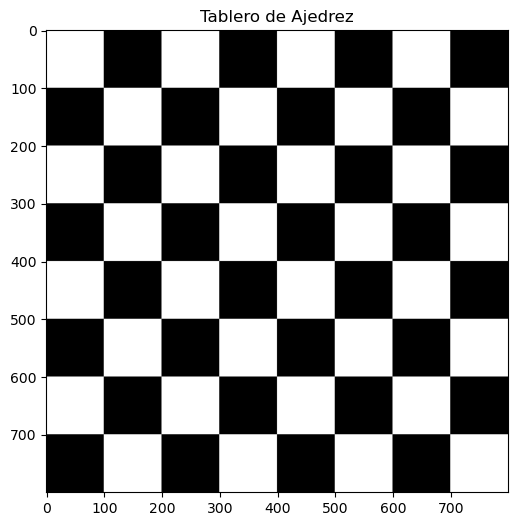

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definir tamaño del tablero
tamano_tablero = 8  # Número de casillas por lado
tamano_casilla = 100  # Tamaño de cada casilla en píxeles


tamano_imagen = tamano_tablero * tamano_casilla
tablero = np.zeros((tamano_imagen, tamano_imagen, 3), dtype=np.uint8)

# dibujar y dar colores
for fila in range(tamano_tablero):
    for columna in range(tamano_tablero):
        if (fila + columna) % 2 == 0:
            tablero[fila * tamano_casilla:(fila + 1) * tamano_casilla,
                    columna * tamano_casilla:(columna + 1) * tamano_casilla] = [255, 255, 255]  # Blanco
        else:
            tablero[fila * tamano_casilla:(fila + 1) * tamano_casilla,
                    columna * tamano_casilla:(columna + 1) * tamano_casilla] = [0, 0, 0]  # Negro

# Mostrar el tablero
plt.figure(figsize=(6, 6))
plt.imshow(tablero)
plt.axis("on") 
plt.title("Ejercicio 1")
plt.show()


Ejercicio 4. 
Tomando en cuenta el ejercicio 2 aplica la ecualización del histograma y muestra el 
mismo viendo las diferencias entre imágenes e histogramas.

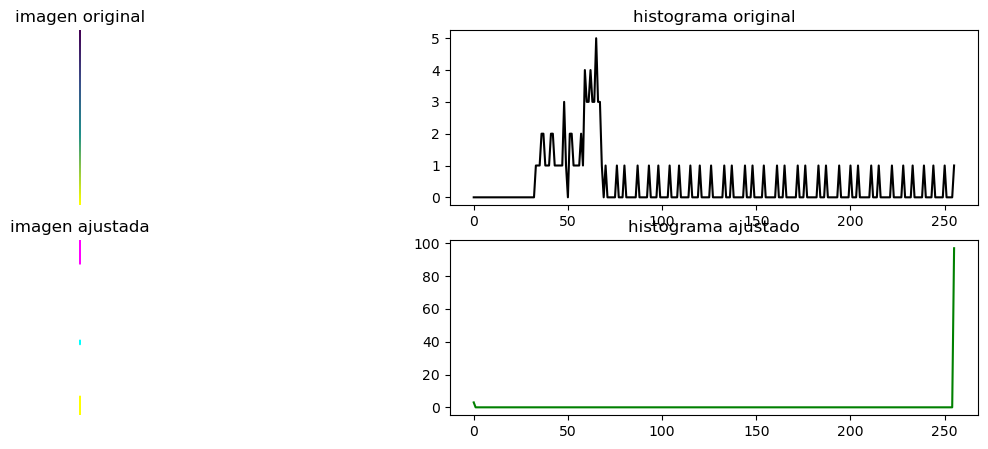

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def ajustar(img, contraste=1.0, brillo=0):
    img = img.astype(np.float32) * 255  
    media = np.mean(img)
    img = media + (img - media) * contraste + brillo
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

#definicion de colores
colores=[(0,'#440154'),(0.3,'#3b528b'),(0.6,'#21918c'),(1,'yellow')] # para escoger los colers
cmap = LinearSegmentedColormap.from_list('degradado', colores)
imagen = (cmap(np.linspace(0, 1, 100).reshape(-1, 1))[:, :, :3] * 255).astype(np.uint8)

factor_brillo = 50
factor_contraste = 1.5
imagen_ajustada = ajustar(imagen, factor_contraste, factor_brillo)


hist1 = cv2.calcHist([imagen], [0], None, [256], [0, 256])
hist2 = cv2.calcHist([imagen_ajustada], [0], None, [256], [0, 256])


plt.figure(figsize=(15, 5))

plt.subplot(221)
plt.title('imagen original')
plt.imshow(imagen)
plt.axis('off')
plt.subplot(222)
plt.title('histograma original')
plt.plot(hist1, color='black')
plt.subplot(223)
plt.title('imagen ajustada')
plt.imshow(imagen_ajustada)
plt.axis('off')
plt.subplot(224)
plt.title('histograma ajustado')
plt.plot(hist2, color='green')
plt.show()

Ejercicio 5. 
Tomando en cuenta la imagen1.jpg aplica un degradado lineal en ella.

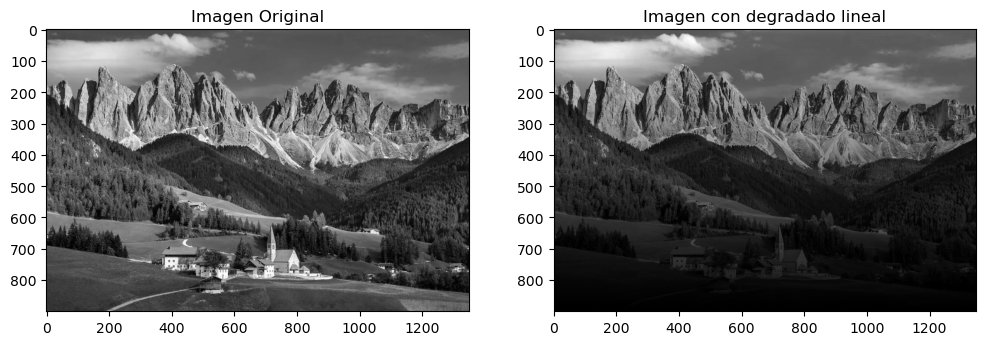

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imagen1.jpg', cv2.IMREAD_GRAYSCALE)


alto, ancho = imagen.shape

# degradar linealmente
degradado = np.linspace(1, 0, alto).reshape(-1, 1)  # Degradado vertical


imagen_degradada = (imagen * degradado).astype(np.uint8)

# Mostrar resultados
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen Original")


plt.subplot(1, 2, 2)
plt.imshow(imagen_degradada, cmap="gray")
plt.title("Imagen con degradado lineal")



plt.show()
